In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/kc_house_data_processed.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(20467, 21)

In [5]:
X = df.drop(["price", "id", "date"], axis=1)
y = df["price"]

In [6]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (20467, 18)
Target: (20467,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (16373, 18)
Testing Features: (4094, 18)
Training Target: (16373,)
Testing Target: (4094,)


In [9]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = lr_model.predict(X_test)

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)
print("R² Score :", r2)

RMSE : 114207.41830005086
MAE  : 86165.0268743705
MAPE : 0.20004809447696853
R² Score : 0.6867899638843775


In [12]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,420000.0,636168.149224
1,230000.0,215201.476288
2,270000.0,303491.285185
3,807000.0,580101.850778
4,225000.0,263232.960055
5,410000.0,469684.724741
6,135000.0,132493.286622
7,550000.0,526770.307869
8,289000.0,271639.209687
9,575000.0,494513.039388


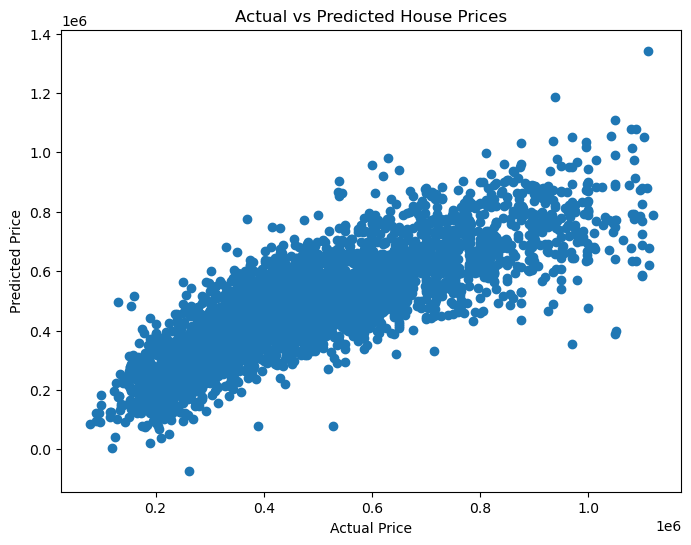

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [14]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
xgb_pred = xgb_model.predict(X_test)

In [16]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost RMSE :", xgb_rmse)
print("XGBoost MAE  :", xgb_mae)
print("XGBoost MAPE :", xgb_mape)
print("XGBoost R² Score :", xgb_r2)

XGBoost RMSE : 73304.64948758522
XGBoost MAE  : 51214.87107657547
XGBoost MAPE : 0.11790788793405142
XGBoost R² Score : 0.8709642400172517


<Figure size 1000x800 with 0 Axes>

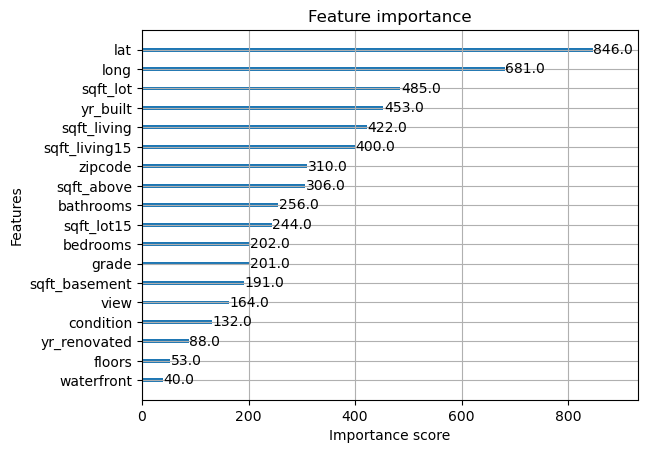

In [17]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(xgb_model)
plt.show()